In [1]:
# Cell 1: Setup
import sys
sys.path.append('..')

from src.evaluation.model_evaluation import ModelEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from config.settings import *

print("📊 Step 4: Model Evaluation & Benchmarking")
print("✅ Ready to evaluate and compare models!")


✅ Config loaded
📊 Step 4: Model Evaluation & Benchmarking
✅ Ready to evaluate and compare models!


In [2]:
# Cell 2: Load models and test data
print("📁 Loading trained models and test data...")

# Load trained models
with open('../models/trained_models.pkl', 'rb') as f:
    trained_models = pickle.load(f)

# Load features and test data
with open('../models/features.pkl', 'rb') as f:
    feature_data = pickle.load(f)

X_test = feature_data['X_test']
y_test = feature_data['y_test']

# Load original cleaned text for VADER
cleaned_data = pd.read_csv(CLEANED_DATA_FILE)

print(f"✅ Loaded {len(trained_models)} trained models")
print(f"✅ Test set: {X_test.shape[0]:,} samples")
print(f"📋 Models: {list(trained_models.keys())}")

📁 Loading trained models and test data...
✅ Loaded 6 trained models
✅ Test set: 19,005 samples
📋 Models: ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'SGD-LogReg', 'Random Forest', 'Ensemble']


In [3]:
# Cell 3: Evaluate all ML models
print("📊 Evaluating all ML models...")

evaluator = ModelEvaluator()
metrics_df, confusion_matrices = evaluator.evaluate_all_models(trained_models, X_test, y_test)

print("\n📈 ML Model Performance:")
print(metrics_df.to_string(index=False))


📊 Evaluating all ML models...
✅ ModelEvaluator ready!
📊 Evaluating all ML models...
🔄 Evaluating Logistic Regression...
✅ Logistic Regression: 75.09% accuracy
🔄 Evaluating Naive Bayes...
✅ Naive Bayes: 73.78% accuracy
🔄 Evaluating Linear SVM...
✅ Linear SVM: 74.38% accuracy
🔄 Evaluating SGD-LogReg...
✅ SGD-LogReg: 75.01% accuracy
🔄 Evaluating Random Forest...
✅ Random Forest: 73.00% accuracy
🔄 Evaluating Ensemble...
✅ Ensemble: 74.91% accuracy

📈 ML Model Performance:
              Model  Accuracy  Precision    Recall  F1-Score
Logistic Regression 75.090766  73.749496 77.435409 75.547521
         SGD-LogReg 75.006577  73.611670 77.477764 75.495254
           Ensemble 74.911865  73.832824 76.694197 75.236315
         Linear SVM 74.375164  73.157149 76.503600 74.792961
        Naive Bayes 73.780584  73.786925 73.263448 73.524255
      Random Forest 72.996580  71.875000 75.010589 73.409326


In [4]:
# Cell 4: Evaluate VADER baseline
print("\n📊 Evaluating VADER (rule-based) baseline...")

# Get test texts (need original text for VADER)
# Split cleaned data same way as features
from sklearn.model_selection import train_test_split
_, test_texts, _, _ = train_test_split(
    cleaned_data['text'], 
    cleaned_data['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=cleaned_data['sentiment']
)

vader_metrics, vader_cm, vader_predictions = evaluator.evaluate_vader_baseline(
    test_texts.values, y_test
)

if vader_metrics:
    print(f"\n✅ VADER Results:")
    for key, value in vader_metrics.items():
        if key != 'Model':
            print(f"   {key}: {value:.2f}%")


📊 Evaluating VADER (rule-based) baseline...
🔄 Evaluating VADER baseline...
✅ VADER: 66.55% accuracy

✅ VADER Results:
   Accuracy: 66.55%
   Precision: 61.05%
   Recall: 90.25%
   F1-Score: 72.83%


In [5]:
# Cell 5: Compare ML models with VADER
print("\n📊 Comparing ML models with VADER baseline...")

comparison_df = evaluator.compare_with_vader(vader_metrics)

print("\n📈 Complete Model Comparison:")
print(comparison_df.to_string(index=False))

# Highlight best models
print(f"\n🏆 Top 3 Models:")
for i, row in comparison_df.head(3).iterrows():
    print(f"{i+1}. {row['Model']}: {row['Accuracy']:.2f}% accuracy")


📊 Comparing ML models with VADER baseline...

📈 Complete Model Comparison:
              Model  Accuracy  Precision    Recall  F1-Score
Logistic Regression 75.090766  73.749496 77.435409 75.547521
         SGD-LogReg 75.006577  73.611670 77.477764 75.495254
           Ensemble 74.911865  73.832824 76.694197 75.236315
         Linear SVM 74.375164  73.157149 76.503600 74.792961
        Naive Bayes 73.780584  73.786925 73.263448 73.524255
      Random Forest 72.996580  71.875000 75.010589 73.409326
 VADER (Rule-Based) 66.545646  61.053009 90.247776 72.833704

🏆 Top 3 Models:
1. Logistic Regression: 75.09% accuracy
2. SGD-LogReg: 75.01% accuracy
3. Ensemble: 74.91% accuracy


In [6]:
# Cell 6: Analyze model strengths and weaknesses
print("\n🔍 Analyzing model strengths and weaknesses...")

# Add VADER confusion matrix to analysis
if vader_cm is not None:
    confusion_matrices['VADER (Rule-Based)'] = vader_cm

analysis_df = evaluator.analyze_model_strengths(confusion_matrices)

print("\n📊 Detailed Model Analysis:")
print(analysis_df[['True Positives', 'True Negatives', 
                   'False Positives', 'False Negatives']].to_string())

print("\n📊 Per-Class Performance:")
print(analysis_df[['Negative Precision', 'Negative Recall',
                   'Positive Precision', 'Positive Recall']].to_string())


🔍 Analyzing model strengths and weaknesses...

🔍 Analyzing model strengths and weaknesses...

📊 Detailed Model Analysis:
                     True Positives  True Negatives  False Positives  False Negatives
Logistic Regression          7313.0          6958.0           2603.0           2131.0
Naive Bayes                  6919.0          7103.0           2458.0           2525.0
Linear SVM                   7225.0          6910.0           2651.0           2219.0
SGD-LogReg                   7317.0          6938.0           2623.0           2127.0
Random Forest                7084.0          6789.0           2772.0           2360.0
Ensemble                     7243.0          6994.0           2567.0           2201.0
VADER (Rule-Based)           8523.0          4124.0           5437.0            921.0

📊 Per-Class Performance:
                     Negative Precision  Negative Recall  Positive Precision  Positive Recall
Logistic Regression           76.554076        72.774814           73.

📊 Creating comprehensive evaluation visualizations...


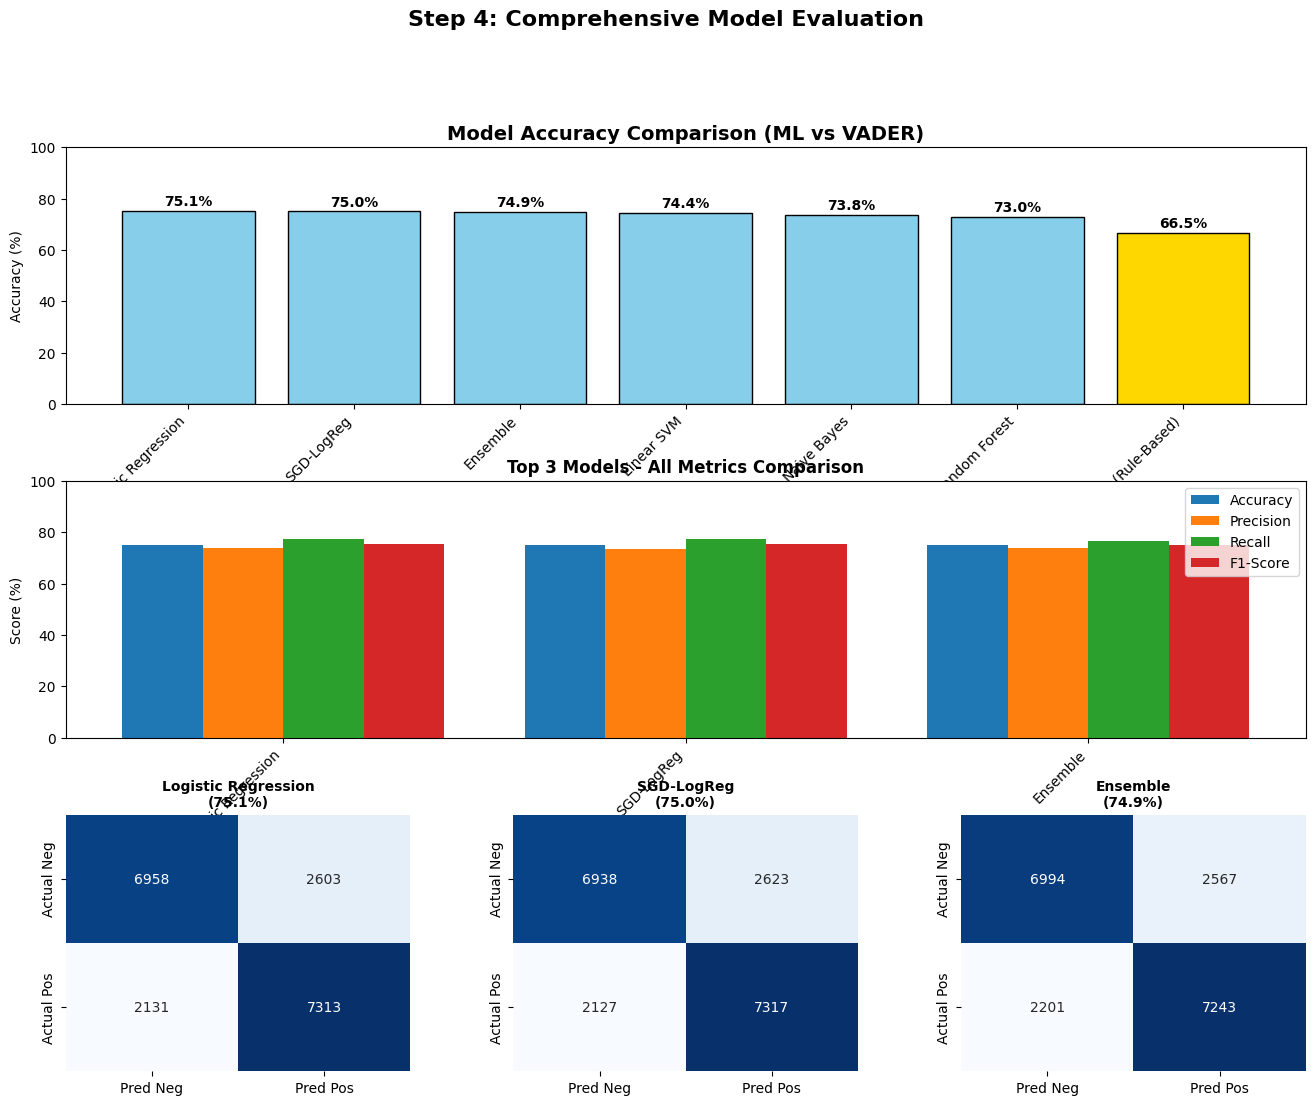

✅ Visualizations complete!


In [7]:
# Cell 7: Visualize comprehensive comparison
print("📊 Creating comprehensive evaluation visualizations...")

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Overall accuracy comparison
ax1 = fig.add_subplot(gs[0, :])
models = comparison_df['Model']
accuracies = comparison_df['Accuracy']
colors = ['gold' if 'VADER' in m else 'skyblue' for m in models]
bars = ax1.bar(models, accuracies, color=colors, edgecolor='black')
ax1.set_title('Model Accuracy Comparison (ML vs VADER)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Add value labels
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. All metrics comparison for top 3
ax2 = fig.add_subplot(gs[1, :])
top_3 = comparison_df.head(3)
x = np.arange(len(top_3))
width = 0.2

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics_to_plot):
    ax2.bar(x + i*width, top_3[metric], width, label=metric)

ax2.set_title('Top 3 Models - All Metrics Comparison', fontweight='bold', fontsize=12)
ax2.set_ylabel('Score (%)')
ax2.set_xlabel('Models')
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(top_3['Model'], rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 100)

# 3-5. Confusion matrices for top 3 models
for idx, (i, row) in enumerate(top_3.iterrows()):
    ax = fig.add_subplot(gs[2, idx])
    model_name = row['Model']
    cm = confusion_matrices[model_name]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['Actual Neg', 'Actual Pos'],
                cbar=False)
    ax.set_title(f'{model_name}\n({row["Accuracy"]:.1f}%)', fontsize=10, fontweight='bold')

plt.suptitle('Step 4: Comprehensive Model Evaluation', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✅ Visualizations complete!")

In [8]:
# Cell 8: Select best model
print("\n🏆 Selecting best ML model for deployment...")

best_model = evaluator.select_best_model(comparison_df, trained_models)

if best_model:
    print("\n📊 Best Model Details:")
    print(f"   Name: {best_model['name']}")
    print(f"   Accuracy: {best_model['accuracy']:.2f}%")
    print(f"   Precision: {best_model['metrics']['Precision']:.2f}%")
    print(f"   Recall: {best_model['metrics']['Recall']:.2f}%")
    print(f"   F1-Score: {best_model['metrics']['F1-Score']:.2f}%")
    
    # Show confusion matrix for best model
    best_cm = confusion_matrices[best_model['name']]
    print(f"\n   Confusion Matrix:")
    print(f"   True Negatives: {best_cm[0,0]:,}")
    print(f"   False Positives: {best_cm[0,1]:,}")
    print(f"   False Negatives: {best_cm[1,0]:,}")
    print(f"   True Positives: {best_cm[1,1]:,}")



🏆 Selecting best ML model for deployment...

🏆 Best ML Model: Logistic Regression
   Accuracy: 75.09%
   Precision: 73.75%
   Recall: 77.44%
   F1-Score: 75.55%

📊 Best Model Details:
   Name: Logistic Regression
   Accuracy: 75.09%
   Precision: 73.75%
   Recall: 77.44%
   F1-Score: 75.55%

   Confusion Matrix:
   True Negatives: 6,958
   False Positives: 2,603
   False Negatives: 2,131
   True Positives: 7,313


In [9]:
# Cell 9: Save all evaluation results
print("\n💾 Saving evaluation results...")

evaluator.save_evaluation_results(comparison_df, confusion_matrices, analysis_df)

# Save best model separately for deployment
best_model_file = '../models/best_model.pkl'
with open(best_model_file, 'wb') as f:
    pickle.dump(best_model, f)

print(f"💾 Saved best model to: {best_model_file}")

print(f"\n🎉 Step 4 Complete!")
print(f"\n📊 Final Summary:")
print(f"   ✅ Evaluated {len(trained_models)} ML models + VADER baseline")
print(f"   ✅ Calculated accuracy, precision, recall, F1-score for all")
print(f"   ✅ Created confusion matrices for all models")
print(f"   ✅ Compared ML models with rule-based VADER")
print(f"   ✅ Analyzed strengths and weaknesses")
print(f"   ✅ Selected best model: {best_model['name']} ({best_model['accuracy']:.2f}%)")
print(f"   ✅ Saved all results for deployment")

print(f"\n🚀 Ready for Step 5: Deployment!")


💾 Saving evaluation results...
💾 Saved comparison to: C:\Res_Projects\social_media_sentiment_analysis\data\processed\final_model_comparison.csv
💾 Saved analysis to: C:\Res_Projects\social_media_sentiment_analysis\data\processed\model_analysis.csv
💾 Saved results to: C:\Res_Projects\social_media_sentiment_analysis\models\evaluation_results.pkl
💾 Saved best model to: ../models/best_model.pkl

🎉 Step 4 Complete!

📊 Final Summary:
   ✅ Evaluated 6 ML models + VADER baseline
   ✅ Calculated accuracy, precision, recall, F1-score for all
   ✅ Created confusion matrices for all models
   ✅ Compared ML models with rule-based VADER
   ✅ Analyzed strengths and weaknesses
   ✅ Selected best model: Logistic Regression (75.09%)
   ✅ Saved all results for deployment

🚀 Ready for Step 5: Deployment!
